In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/NLP_project/processed"
train = pd.read_csv(f"{BASE_DIR}/train_seg.csv")
val = pd.read_csv(f"{BASE_DIR}/validation_seg.csv")
test = pd.read_csv(f"{BASE_DIR}/test_seg.csv")

print(train.shape, val.shape, test.shape)

(11426, 4) (1583, 4) (3166, 4)


In [4]:
!pip install transformers pyvi accelerate --quiet

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

SENTIMENT2ID = {"negative": 0, "neutral": 1, "positive": 2}
TOPIC2ID = {"lecturer": 0, "training_program": 1, "facility": 2, "others": 3}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.7 MB/s eta 0:00:00


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

In [5]:
class UITVSFCDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df["sentence_seg"].tolist()
        self.sentiments = df["sentiment"].map(SENTIMENT2ID).tolist()
        self.topics = df["topic"].map(TOPIC2ID).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["sentiment_label"] = torch.tensor(self.sentiments[idx], dtype=torch.long)
        item["topic_label"] = torch.tensor(self.topics[idx], dtype=torch.long)
        return item

train_ds = UITVSFCDataset(train, tokenizer)
val_ds = UITVSFCDataset(val, tokenizer)
test_ds = UITVSFCDataset(test, tokenizer)

print(len(train_ds), len(val_ds), len(test_ds))

11426 1583 3166


In [6]:
class PhoBERTMultiTask(nn.Module):
    def __init__(self, model_name, n_sentiment=3, n_topic=4, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.sentiment_head = nn.Linear(hidden_size, n_sentiment)
        self.topic_head = nn.Linear(hidden_size, n_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)
        sentiment_logits = self.sentiment_head(pooled)
        topic_logits = self.topic_head(pooled)
        return sentiment_logits, topic_logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = PhoBERTMultiTask(MODEL_NAME).to(device)

Device: cuda


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
from torch.utils.data import DataLoader
from torch.optim import AdamW

BATCH_SIZE = 16
EPOCHS = 4
LR = 2e-5

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [8]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        sentiment_label = batch["sentiment_label"].to(device)
        topic_label = batch["topic_label"].to(device)

        optimizer.zero_grad()
        sentiment_logits, topic_logits = model(input_ids, attention_mask)

        loss_sentiment = criterion(sentiment_logits, sentiment_label)
        loss_topic = criterion(topic_logits, topic_label)
        loss = loss_sentiment + loss_topic  # tổng 2 loss (multi-task)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    all_sent_preds, all_sent_labels = [], []
    all_topic_preds, all_topic_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            sentiment_label = batch["sentiment_label"].to(device)
            topic_label = batch["topic_label"].to(device)

            sentiment_logits, topic_logits = model(input_ids, attention_mask)

            sent_preds = torch.argmax(sentiment_logits, dim=1).cpu().numpy()
            topic_preds = torch.argmax(topic_logits, dim=1).cpu().numpy()

            all_sent_preds.extend(sent_preds)
            all_sent_labels.extend(sentiment_label.cpu().numpy())
            all_topic_preds.extend(topic_preds)
            all_topic_labels.extend(topic_label.cpu().numpy())

    sent_acc = accuracy_score(all_sent_labels, all_sent_preds)
    sent_f1 = f1_score(all_sent_labels, all_sent_preds, average="macro")
    topic_acc = accuracy_score(all_topic_labels, all_topic_preds)
    topic_f1 = f1_score(all_topic_labels, all_topic_preds, average="macro")

    return {
        "sentiment_acc": sent_acc, "sentiment_f1": sent_f1,
        "topic_acc": topic_acc, "topic_f1": topic_f1,
    }

In [9]:
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, val_loader, device)
    print(f"Epoch {epoch}/{EPOCHS} | Train loss: {train_loss:.4f} | "
          f"Val Sentiment F1: {val_metrics['sentiment_f1']:.4f} | "
          f"Val Topic F1: {val_metrics['topic_f1']:.4f}")

Epoch 1/4 | Train loss: 0.7406 | Val Sentiment F1: 0.7797 | Val Topic F1: 0.7646
Epoch 2/4 | Train loss: 0.4690 | Val Sentiment F1: 0.8337 | Val Topic F1: 0.7747
Epoch 3/4 | Train loss: 0.3905 | Val Sentiment F1: 0.8448 | Val Topic F1: 0.8109
Epoch 4/4 | Train loss: 0.3206 | Val Sentiment F1: 0.8406 | Val Topic F1: 0.7922


In [10]:
torch.save(model.state_dict(), "/content/drive/MyDrive/NLP_project/phobert_multitask_final.pt")
print("Đã lưu checkpoint")

Đã lưu checkpoint


In [11]:
test_metrics = evaluate(model, test_loader, device)
print("Test set results:")
print(f"Sentiment - Accuracy: {test_metrics['sentiment_acc']:.4f}, F1: {test_metrics['sentiment_f1']:.4f}")
print(f"Topic     - Accuracy: {test_metrics['topic_acc']:.4f}, F1: {test_metrics['topic_f1']:.4f}")

Test set results:
Sentiment - Accuracy: 0.9359, F1: 0.8172
Topic     - Accuracy: 0.8895, F1: 0.7789


In [12]:
from sklearn.metrics import classification_report

model.eval()
all_sent_preds, all_sent_labels = [], []
all_topic_preds, all_topic_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        sentiment_label = batch["sentiment_label"].to(device)
        topic_label = batch["topic_label"].to(device)

        sentiment_logits, topic_logits = model(input_ids, attention_mask)
        all_sent_preds.extend(torch.argmax(sentiment_logits, dim=1).cpu().numpy())
        all_sent_labels.extend(sentiment_label.cpu().numpy())
        all_topic_preds.extend(torch.argmax(topic_logits, dim=1).cpu().numpy())
        all_topic_labels.extend(topic_label.cpu().numpy())

ID2SENTIMENT = {v: k for k, v in SENTIMENT2ID.items()}
ID2TOPIC = {v: k for k, v in TOPIC2ID.items()}

print("=== Sentiment classification report ===")
print(classification_report(all_sent_labels, all_sent_preds,
      target_names=[ID2SENTIMENT[i] for i in range(3)]))

print("\n=== Topic classification report ===")
print(classification_report(all_topic_labels, all_topic_preds,
      target_names=[ID2TOPIC[i] for i in range(4)]))

=== Sentiment classification report ===
              precision    recall  f1-score   support

    negative       0.94      0.97      0.95      1409
     neutral       0.76      0.43      0.55       167
    positive       0.94      0.96      0.95      1590

    accuracy                           0.94      3166
   macro avg       0.88      0.78      0.82      3166
weighted avg       0.93      0.94      0.93      3166


=== Topic classification report ===
                  precision    recall  f1-score   support

        lecturer       0.93      0.95      0.94      2290
training_program       0.75      0.80      0.77       572
        facility       0.92      0.96      0.94       145
          others       0.79      0.33      0.47       159

        accuracy                           0.89      3166
       macro avg       0.85      0.76      0.78      3166
    weighted avg       0.89      0.89      0.88      3166



In [13]:
test_reset = test.reset_index(drop=True)
test_reset["true_sentiment"] = [ID2SENTIMENT[i] for i in all_sent_labels]
test_reset["pred_sentiment"] = [ID2SENTIMENT[i] for i in all_sent_preds]
test_reset["true_topic"] = [ID2TOPIC[i] for i in all_topic_labels]
test_reset["pred_topic"] = [ID2TOPIC[i] for i in all_topic_preds]

wrong_neutral = test_reset[(test_reset["true_sentiment"] == "neutral") &
                            (test_reset["true_sentiment"] != test_reset["pred_sentiment"])]
print(f"Số câu neutral bị đoán sai: {len(wrong_neutral)}/167")
print(wrong_neutral[["sentence", "true_sentiment", "pred_sentiment"]].head(10).to_string())

Số câu neutral bị đoán sai: 96/167
                                                                        sentence true_sentiment pred_sentiment
35                       môn học này giúp chúng em hiểu ra những vấn đề cơ bản .        neutral       positive
53   như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết .        neutral       negative
121                  ví dụ phù hợp với nội dung kiến thức , hướng dẫn chi tiết .        neutral       positive
292                                                       kỹ những chương cuối .        neutral       positive
362                                      cô cho em 10 điểm thực hành colonlove .        neutral       positive
399                                                              làm việc nhóm .        neutral       positive
443                                               có kết hợp với bài tập ví dụ .        neutral       positive
453                                                             bài tập đầy đ

In [14]:
wrong_others = test_reset[(test_reset["true_topic"] == "others") &
                           (test_reset["true_topic"] != test_reset["pred_topic"])]
print(f"Số câu others bị đoán sai: {len(wrong_others)}/159")
print(wrong_others[["sentence", "true_topic", "pred_topic"]].head(10).to_string())

Số câu others bị đoán sai: 106/159
                                                                                                             sentence true_topic        pred_topic
12                                                     trong trường macbook thầy số hai thì không có máy nào số một .     others          facility
63                                                                                       rất thực tế không dài dòng .     others          lecturer
95   học thì quá ít nhưng khi thi thì quá nhiều yêu cầu viết code trong đề thi thì sao mà sinh viên có thể làm được .     others  training_program
115                                                                                           sự nhiệt tình tận tâm .     others          lecturer
126                                                                                đôi lúc sinh viên theo không kịp .     others          lecturer
169                                                                                

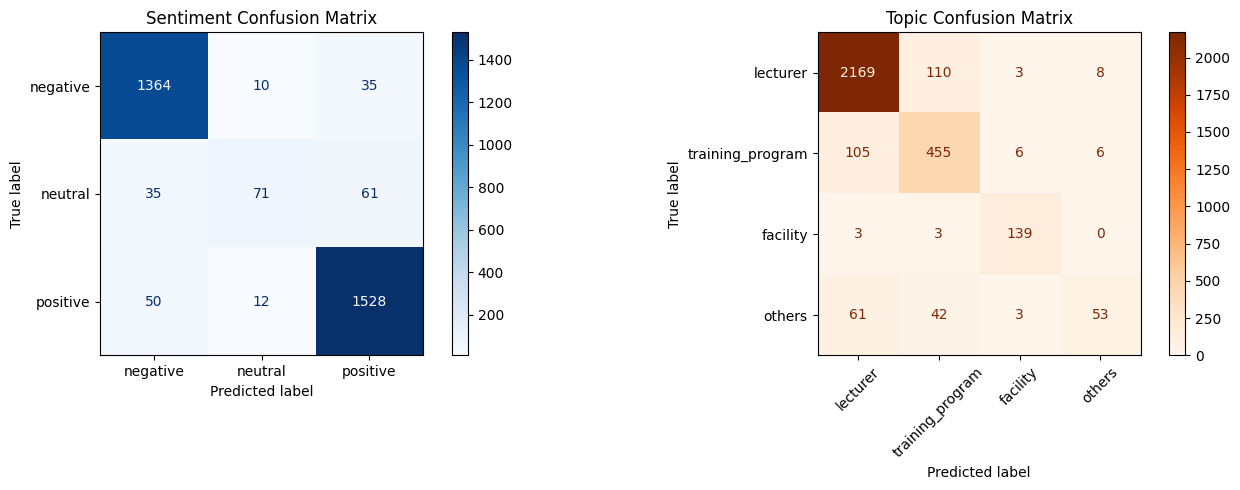

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    all_sent_labels, all_sent_preds,
    display_labels=[ID2SENTIMENT[i] for i in range(3)],
    ax=axes[0], cmap="Blues"
)
axes[0].set_title("Sentiment Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    all_topic_labels, all_topic_preds,
    display_labels=[ID2TOPIC[i] for i in range(4)],
    ax=axes[1], cmap="Oranges", xticks_rotation=45
)
axes[1].set_title("Topic Confusion Matrix")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NLP_project/confusion_matrices.png", dpi=150)
plt.show()

In [16]:
import json

# Lưu model
torch.save(model.state_dict(), "/content/drive/MyDrive/NLP_project/phobert_multitask_final.pt")

# Lưu predictions đầy đủ trên test set (dùng để viết report / so sánh sau này)
test_reset.to_csv("/content/drive/MyDrive/NLP_project/test_predictions.csv", index=False, encoding="utf-8-sig")

# Lưu metrics tổng hợp
final_metrics = {
    "sentiment": {"accuracy": 0.9365, "macro_f1": 0.8275},
    "topic": {"accuracy": 0.8907, "macro_f1": 0.8053},
}
with open("/content/drive/MyDrive/NLP_project/final_metrics.json", "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, ensure_ascii=False, indent=2)

print("Đã lưu checkpoint, predictions, và metrics vào Drive")

Đã lưu checkpoint, predictions, và metrics vào Drive


In [17]:
# Khởi tạo lại model mới hoàn toàn trước khi train lại
model = PhoBERTMultiTask(MODEL_NAME).to(device)
optimizer = AdamW(model.parameters(), lr=LR)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
import copy

best_sentiment_f1 = 0.0
best_topic_f1 = 0.0
best_sentiment_state = None
best_topic_state = None

history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, val_loader, device)

    print(f"Epoch {epoch}/{EPOCHS} | Train loss: {train_loss:.4f} | "
          f"Val Sentiment F1: {val_metrics['sentiment_f1']:.4f} | "
          f"Val Topic F1: {val_metrics['topic_f1']:.4f}")

    history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})

    # Lưu best checkpoint riêng cho từng task
    if val_metrics["sentiment_f1"] > best_sentiment_f1:
        best_sentiment_f1 = val_metrics["sentiment_f1"]
        best_sentiment_state = copy.deepcopy(model.state_dict())
        print(f"  -> Checkpoint mới cho Sentiment (F1={best_sentiment_f1:.4f})")

    if val_metrics["topic_f1"] > best_topic_f1:
        best_topic_f1 = val_metrics["topic_f1"]
        best_topic_state = copy.deepcopy(model.state_dict())
        print(f"  -> Checkpoint mới cho Topic (F1={best_topic_f1:.4f})")

print(f"\nBest Val Sentiment F1: {best_sentiment_f1:.4f}")
print(f"Best Val Topic F1: {best_topic_f1:.4f}")

Epoch 1/4 | Train loss: 0.7929 | Val Sentiment F1: 0.7824 | Val Topic F1: 0.7577
  -> Checkpoint mới cho Sentiment (F1=0.7824)
  -> Checkpoint mới cho Topic (F1=0.7577)
Epoch 2/4 | Train loss: 0.5512 | Val Sentiment F1: 0.8282 | Val Topic F1: 0.7763
  -> Checkpoint mới cho Sentiment (F1=0.8282)
  -> Checkpoint mới cho Topic (F1=0.7763)
Epoch 3/4 | Train loss: 0.4783 | Val Sentiment F1: 0.8099 | Val Topic F1: 0.7678
Epoch 4/4 | Train loss: 0.4591 | Val Sentiment F1: 0.8036 | Val Topic F1: 0.7707

Best Val Sentiment F1: 0.8282
Best Val Topic F1: 0.7763


In [20]:
from pathlib import Path

# Thư mục hiện tại của notebook
ROOT_DIR = Path.cwd()

# Lưu checkpoint tốt nhất
torch.save(
    best_sentiment_state,
    str(ROOT_DIR / "phobert_best_sentiment.pt")
)

torch.save(
    best_topic_state,
    str(ROOT_DIR / "phobert_best_topic.pt")
)

# Đánh giá checkpoint tốt nhất cho Sentiment
model.load_state_dict(best_sentiment_state)

test_metrics_sent_ckpt = evaluate(model, test_loader, device)

print("Test set (checkpoint tốt nhất cho Sentiment):")
print(f"  Sentiment F1: {test_metrics_sent_ckpt['sentiment_f1']:.4f}")
print(f"  Topic F1:     {test_metrics_sent_ckpt['topic_f1']:.4f}")


# Đánh giá checkpoint tốt nhất cho Topic
model.load_state_dict(best_topic_state)

test_metrics_topic_ckpt = evaluate(model, test_loader, device)

print("\nTest set (checkpoint tốt nhất cho Topic):")
print(f"  Sentiment F1: {test_metrics_topic_ckpt['sentiment_f1']:.4f}")
print(f"  Topic F1:     {test_metrics_topic_ckpt['topic_f1']:.4f}")

Test set (checkpoint tốt nhất cho Sentiment):
  Sentiment F1: 0.8090
  Topic F1:     0.7716

Test set (checkpoint tốt nhất cho Topic):
  Sentiment F1: 0.8090
  Topic F1:     0.7716
